In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib, os, sys

sys.path.append(os.path.join(os.getcwd(), '..'))
from config import TARGET, ALERT_THRESHOLD

In [ ]:
best_model        = joblib.load('../models/best_model.pkl')
X_test_scaled     = joblib.load('../models/X_test.pkl')
y_test            = joblib.load('../models/y_test.pkl')
selected_features = joblib.load('../models/feature_names.pkl')

# Wrap in DataFrame so SHAP shows feature names
X_test_df = pd.DataFrame(X_test_scaled, columns=selected_features)

print("Model         :", type(best_model).__name__)
print("Test samples  :", X_test_df.shape)
print("Fraud cases   :", y_test.sum())

Model         : XGBClassifier
Test samples  : (1817, 114)
Fraud cases   : 16


In [ ]:
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_df)

print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1817, 114)


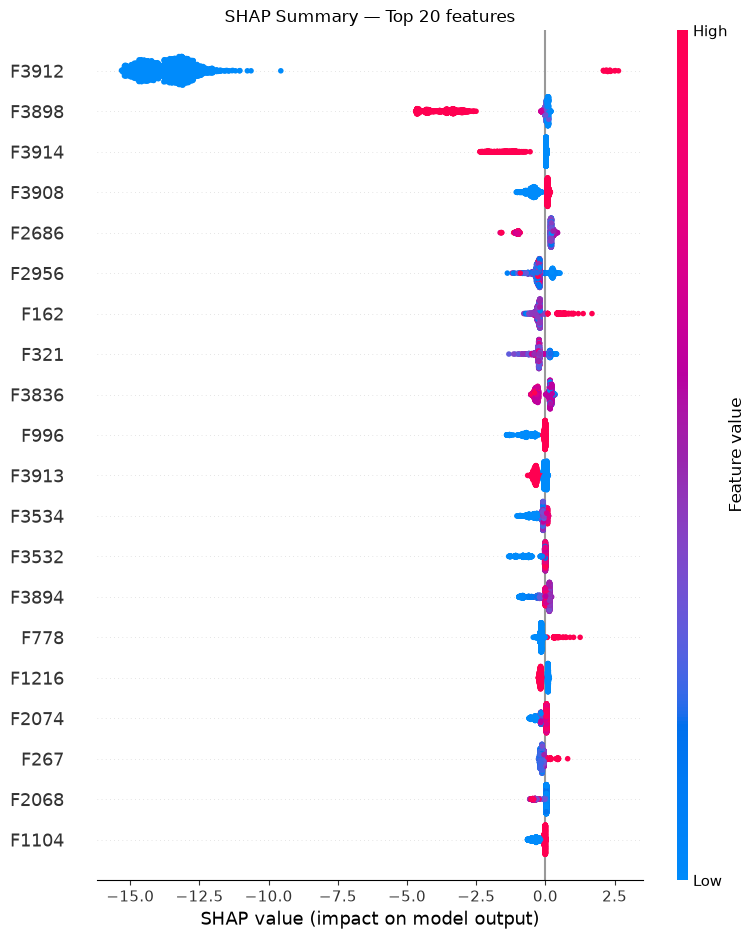

Saved shap_summary.png


In [ ]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_df,
    feature_names=selected_features,
    max_display=20,
    show=False
)
plt.title("SHAP Summary — Top 20 features")
plt.tight_layout()
plt.savefig("../reports/figures/shap_summary.png", bbox_inches='tight')
plt.show()
print("Saved shap_summary.png")

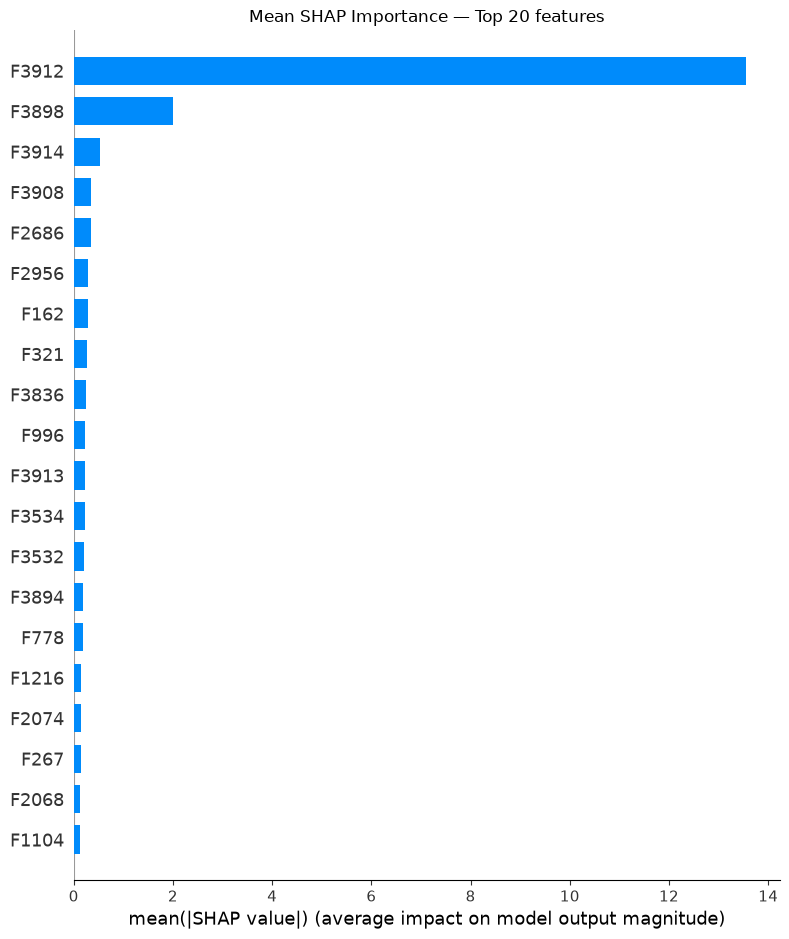

Saved shap_bar.png


In [ ]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_df,
    feature_names=selected_features,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Mean SHAP Importance — Top 20 features")
plt.tight_layout()
plt.savefig("../reports/figures/shap_bar.png", bbox_inches='tight')
plt.show()
print("Saved shap_bar.png")

Top 10 features driving fraud detection:

   1. F3912            →  mean |SHAP| = 13.5588
   2. F3898            →  mean |SHAP| = 2.0057
   3. F3914            →  mean |SHAP| = 0.5337
   4. F3908            →  mean |SHAP| = 0.3508
   5. F2686            →  mean |SHAP| = 0.3484
   6. F2956            →  mean |SHAP| = 0.2972
   7. F162             →  mean |SHAP| = 0.2822
   8. F321             →  mean |SHAP| = 0.2624
   9. F3836            →  mean |SHAP| = 0.2544
  10. F996             →  mean |SHAP| = 0.2335


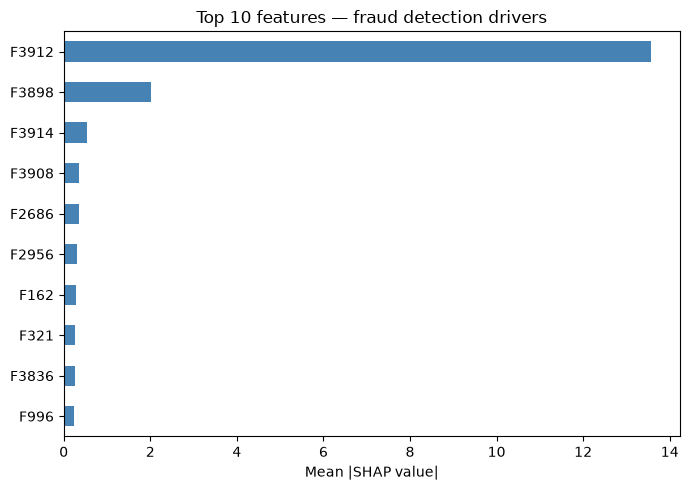

In [ ]:
shap_df = pd.DataFrame(
    np.abs(shap_values),
    columns=selected_features
)

importance = shap_df.mean().sort_values(ascending=False).head(10)

print("Top 10 features driving fraud detection:\n")
for rank, (feat, score) in enumerate(importance.items(), 1):
    print(f"  {rank:2}. {feat:15s}  →  mean |SHAP| = {score:.4f}")

plt.figure(figsize=(7, 5))
importance.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel("Mean |SHAP value|")
plt.title("Top 10 features — fraud detection drivers")
plt.tight_layout()
plt.savefig("../reports/figures/shap_top10.png")
plt.show()

Fraud cases in test set: 16

Explaining fraud case at index 55
Risk score : 1.0000


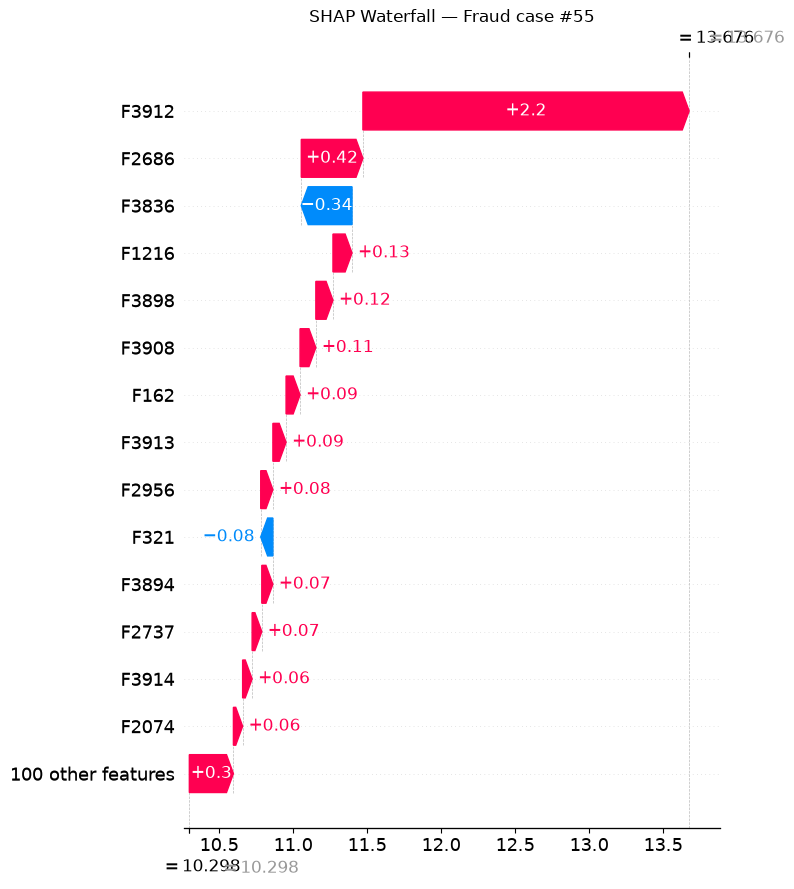

In [ ]:
# Get indices of actual fraud cases in test set
fraud_indices = np.where(y_test.values == 1)[0]
print(f"Fraud cases in test set: {len(fraud_indices)}")

# Pick first fraud case and explain it
idx = fraud_indices[0]

print(f"\nExplaining fraud case at index {idx}")
print(f"Risk score : {best_model.predict_proba(X_test_df)[idx][1]:.4f}")

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[idx],
    feature_names=selected_features,
    max_display=15,
    show=False
)
plt.title(f"SHAP Waterfall — Fraud case #{idx}")
plt.tight_layout()
plt.savefig("../reports/figures/shap_waterfall_fraud.png", bbox_inches='tight')
plt.show()

Explaining legit case at index 0
Risk score : 0.0000


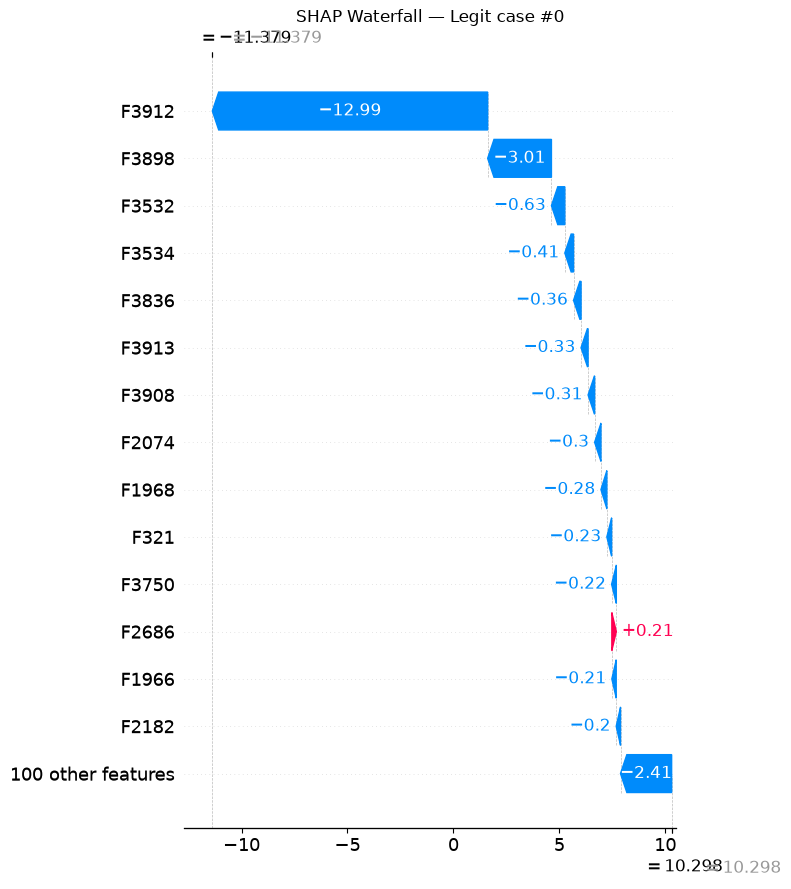

In [ ]:
legit_indices = np.where(y_test.values == 0)[0]
idx_legit     = legit_indices[0]

print(f"Explaining legit case at index {idx_legit}")
print(f"Risk score : {best_model.predict_proba(X_test_df)[idx_legit][1]:.4f}")

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[idx_legit],
    feature_names=selected_features,
    max_display=15,
    show=False
)
plt.title(f"SHAP Waterfall — Legit case #{idx_legit}")
plt.tight_layout()
plt.savefig("../reports/figures/shap_waterfall_legit.png", bbox_inches='tight')
plt.show()

In [ ]:
y_prob = best_model.predict_proba(X_test_df)[:, 1]

fraud_report = X_test_df.iloc[fraud_indices].copy()
fraud_report["risk_score"] = y_prob[fraud_indices]
fraud_report["true_label"] = y_test.values[fraud_indices]
fraud_report["alert"]      = fraud_report["risk_score"] >= 0.38

# Show top features + risk score
top_feats = importance.index.tolist()[:5]
display_cols = top_feats + ["risk_score", "alert"]

print("=== FRAUD CASES WITH RISK SCORES ===\n")
print(fraud_report[display_cols].to_string())

=== FRAUD CASES WITH RISK SCORES ===

          F3912     F3898     F3914     F3908       F2686  risk_score  alert
55    10.443934 -0.394065 -0.676941  1.514362   -0.009283    0.999999   True
98    10.443934 -0.394065 -0.676941  1.514362   -0.009283    0.999989   True
217   10.443934 -0.848202 -0.676941  1.514362   -0.028956    0.999999   True
497   10.443934 -0.848202 -0.676941 -0.660344  161.909355    0.999939   True
740   10.443934 -0.848202 -0.676941  1.514362   -0.009283    0.999998   True
831   10.443934 -0.848202 -0.676941  1.514362   -0.009283    1.000000   True
846   10.443934 -0.394065 -0.676941  1.514362    0.000553    0.999990   True
856   10.443934 -0.848202 -0.676941  1.514362   -0.019939    0.999997   True
997   10.443934 -0.848202 -0.676941  1.514362   -0.001906    0.999988   True
1103  10.443934 -0.848202 -0.676941  1.514362    0.020225    0.999964   True
1107  10.443934 -0.848202 -0.676941  1.514362   -0.011742    0.999999   True
1133  10.443934 -0.394065 -0.676941  1

In [ ]:
import json

with open("../reports/metrics.json") as f:
    metrics = json.load(f)

print("=" * 50)
print("   MULE ACCOUNT DETECTION — FINAL SUMMARY")
print("=" * 50)
print(f"  Model              : {type(best_model).__name__}")
print(f"  Total accounts     : 9,082")
print(f"  Fraud accounts     : 81  (0.89%)")
print(f"  AUC-ROC            : {metrics['AUC_ROC']}")
print(f"  AUC-PR             : {metrics['AUC_PR']}")
print(f"  Best F1            : {metrics['Best_F1']}")
print(f"  Best Threshold     : {metrics['Best_Threshold']}")
print(f"  True Positives     : {metrics['True_Positives']}  (fraud caught)")
print(f"  False Positives    : {metrics['False_Positives']} (legit wrongly flagged)")
print(f"  False Negatives    : {metrics['False_Negatives']} (fraud missed)")
print("=" * 50)
print("  All plots saved to reports/figures/")
print("=" * 50)

   MULE ACCOUNT DETECTION — FINAL SUMMARY
  Model              : XGBClassifier
  Total accounts     : 9,082
  Fraud accounts     : 81  (0.89%)
  AUC-ROC            : 1.0
  AUC-PR             : 1.0
  Best F1            : 1.0
  Best Threshold     : 0.38
  True Positives     : 16  (fraud caught)
  False Positives    : 0 (legit wrongly flagged)
  False Negatives    : 0 (fraud missed)
  All plots saved to reports/figures/
